# 🏡 Proyecto de Regresión: Predicción de Precios de Viviendas en California

En este cuaderno, aplicaremos el flujo de trabajo completo de un proyecto de Machine Learning para resolver un problema de **regresión**: predecir el valor mediano de las viviendas en distritos de California.

Utilizaremos el conjunto de datos **California Housing**, que es un dataset clásico disponible en Scikit-learn.

## 🎯 Objetivos

1.  **Cargar y Explorar los Datos (EDA)**: Entender la estructura, características y distribución de los datos.
2.  **Visualizar los Datos**: Crear gráficos para descubrir patrones y correlaciones.
3.  **Preparar los Datos**: Dividir en conjuntos de entrenamiento/prueba y escalar las características.
4.  **Entrenar Múltiples Modelos**: Implementar y entrenar modelos de regresión como `LinearRegression`, `Ridge`, `Lasso` y `RandomForestRegressor`.
5.  **Evaluar los Modelos**: Medir el rendimiento de cada modelo utilizando métricas como MAE, MSE y R².
6.  **Analizar Resultados**: Comparar los modelos y extraer conclusiones.

## 📚 Paso 1: Importar las Librerías Necesarias

Primero, importamos todas las herramientas que necesitaremos para nuestro análisis.

In [2]:
# Manipulación y análisis de datos
import numpy as np
import pandas as pd

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


# Carga de datos y preprocesamiento
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Modelos de Regresión
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

# Métricas de evaluación
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuración para visualizaciones
plt.style.use('default')
sns.set(style='whitegrid')
%matplotlib inline 

# Evitar warnings innecesarios
import warnings
warnings.filterwarnings('ignore')

print('✅ Librerías importadas correctamente.')

✅ Librerías importadas correctamente.


## 📊 Paso 2: Cargar y Explorar los Datos (EDA)

Cargamos el dataset `California Housing` desde Scikit-learn. Este dataset ya viene limpio y listo para usar.

In [ ]:
# Cargar el dataset desde sklearn
# california = fetch_california_housing()

# Cargar el dataset desde csv
california = pd.read_csv('housing.csv')

# El objeto 'california' es un diccionario. Exploremos sus claves.
print('Claves del dataset:', california.keys())

# Descripción del dataset
print('\nDescripción del dataset:')

'''
1. longitude: A measure of how far west a house is; a higher value is farther west

2. latitude: A measure of how far north a house is; a higher value is farther north

3. housingMedianAge: Edad media de una vivienda dentro de una manzana; un número más bajo indica un edificio más nuevo.

4. totalRooms: Número total de habitaciones dentro de una manzana.

5. totalBedrooms: Número total de dormitorios dentro de una manzana.

6. population: Número total de personas que residen dentro de una manzana.

7. households: Número total de hogares, un grupo de personas que residen dentro de una unidad de vivienda, para una manzana.

8. medianIncome: Ingresos medios de los hogares dentro de una manzana (medidos en decenas de miles de dólares estadounidenses).

9. medianHouseValue: Valor medio de las viviendas de los hogares dentro de una manzana (medido en dólares estadounidenses).

10. oceanProximity: Ubicación de la vivienda con respecto al océano/mar.'''

Claves del dataset: Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

Descripción del dataset:


'\n1. longitude: A measure of how far west a house is; a higher value is farther west\n\n2. latitude: A measure of how far north a house is; a higher value is farther north\n\n3. housingMedianAge: Median age of a house within a block; a lower number is a newer building\n\n4. totalRooms: Total number of rooms within a block\n\n5. totalBedrooms: Total number of bedrooms within a block\n\n6. population: Total number of people residing within a block\n\n7. households: Total number of households, a group of people residing within a home unit, for a block\n\n8. medianIncome: Median income for households within a block of houses (measured in tens of thousands of US Dollars)\n\n9. medianHouseValue: Median house value for households within a block (measured in US Dollars)\n\n10. oceanProximity: Location of the house w.r.t ocean/sea'

### Convertir a DataFrame de Pandas

Para facilitar la manipulación y visualización, convertimos los datos a un DataFrame de Pandas.

In [4]:
# Convertir a DataFrame para facilitar su manipulación
df = pd.DataFrame(california)

print('Primeras 5 filas del DataFrame:')
display(df.head())

Primeras 5 filas del DataFrame:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Información General y Estadísticas

Veamos un resumen de la estructura y estadísticas descriptivas.

In [5]:
# Información general (tipos de datos, valores no nulos)
print('Información del DataFrame:')
display(df.info())

# Estadísticas descriptivas
print('\nEstadísticas Descriptivas:')
display(df.describe())

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


None


Estadísticas Descriptivas:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## 📈 Paso 3: Visualización de Datos

La visualización es clave para entender las relaciones entre las variables.

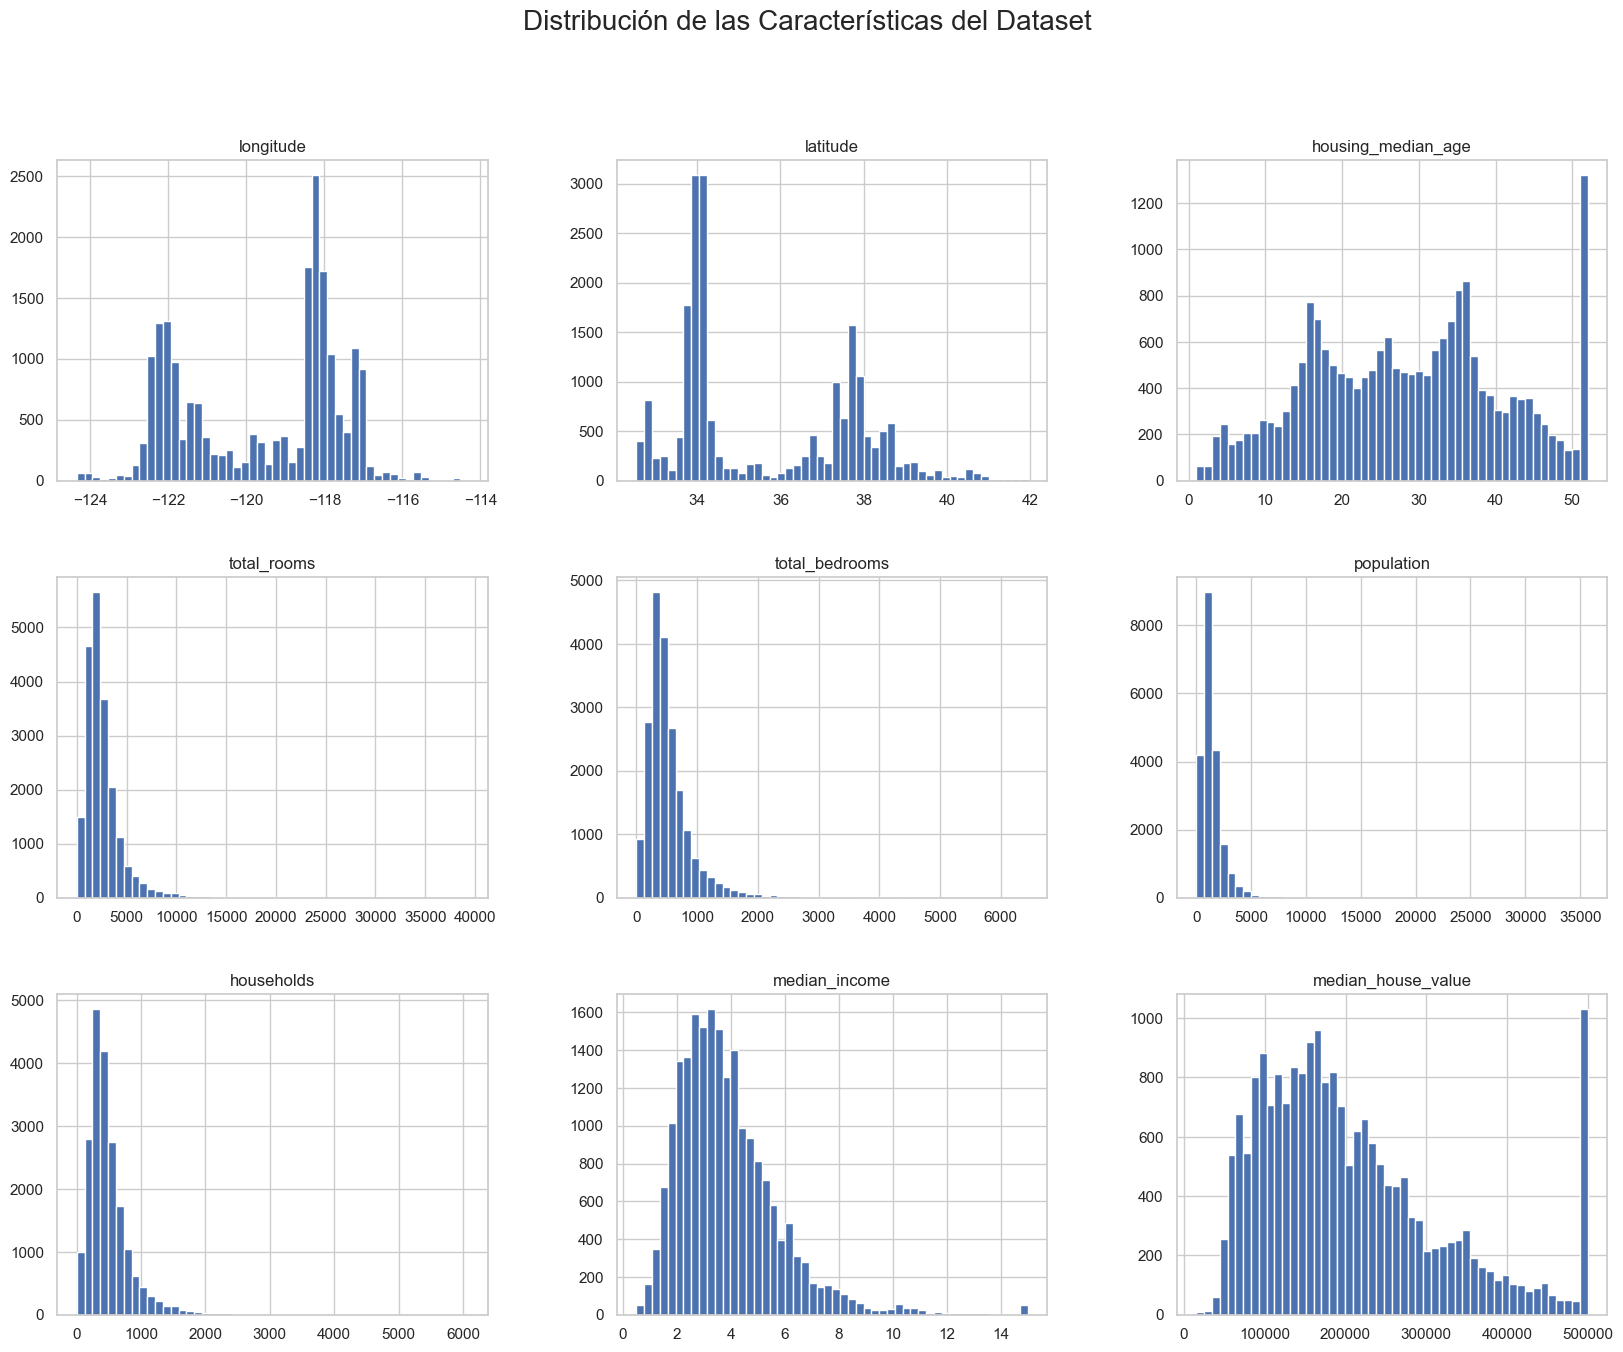

In [6]:
# Histogramas de todas las características para ver su distribución
df.hist(bins=50, figsize=(20, 15))
plt.suptitle('Distribución de las Características del Dataset', size=20)
plt.show()

### Visualización Geográfica de Precios

Un scatter plot de latitud y longitud nos dará una idea de cómo se distribuyen los precios geográficamente.

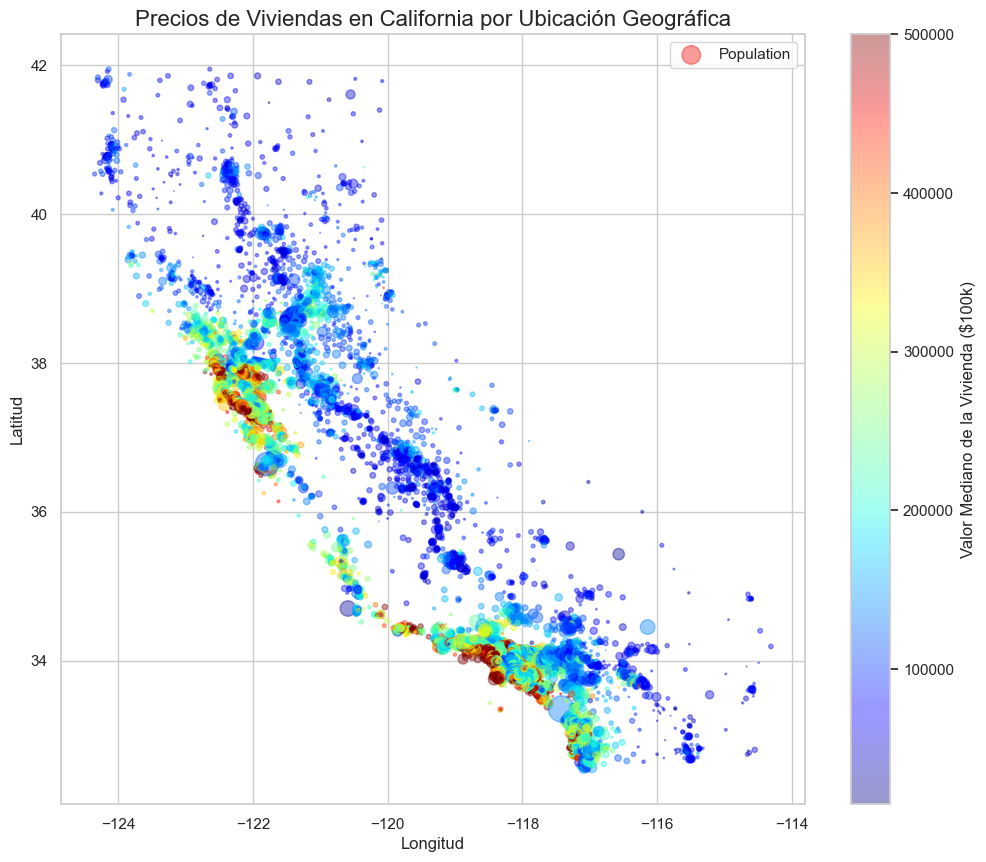

In [8]:
plt.figure(figsize=(12, 10))
scatter = plt.scatter(df['longitude'], df['latitude'], alpha=0.4,
                    s=df['population']/100, label='Population',
                    c=df['median_house_value'], cmap=plt.get_cmap('jet'))
plt.colorbar(scatter).set_label('Valor Mediano de la Vivienda ($100k)')
plt.title('Precios de Viviendas en California por Ubicación Geográfica', fontsize=16)
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend()
plt.show()

### Matriz de Correlación

Veamos qué características están más correlacionadas con el precio de la vivienda.

In [13]:
# Cuantas clases tiene ocean_proximity
print('\nClases en ocean_proximity:')
print(df['ocean_proximity'].value_counts())
# Convertimos la columna a numérica usando one-hot encoding
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True) 
print('\nPrimeras 5 filas del DataFrame después de one-hot encoding:')
display(df.head())


Clases en ocean_proximity:


KeyError: 'ocean_proximity'

In [17]:
# Completamos datos faltantes en 'total_bedrooms' con la mediana
df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)
# Visualizamos si quedan datos faltantes
print('\nDatos faltantes por columna después de la imputación:')
print(df.isnull().sum())



Datos faltantes por columna después de la imputación:
longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms                0
population                    0
households                    0
median_income                 0
median_house_value            0
ocean_proximity_INLAND        0
ocean_proximity_ISLAND        0
ocean_proximity_NEAR BAY      0
ocean_proximity_NEAR OCEAN    0
dtype: int64


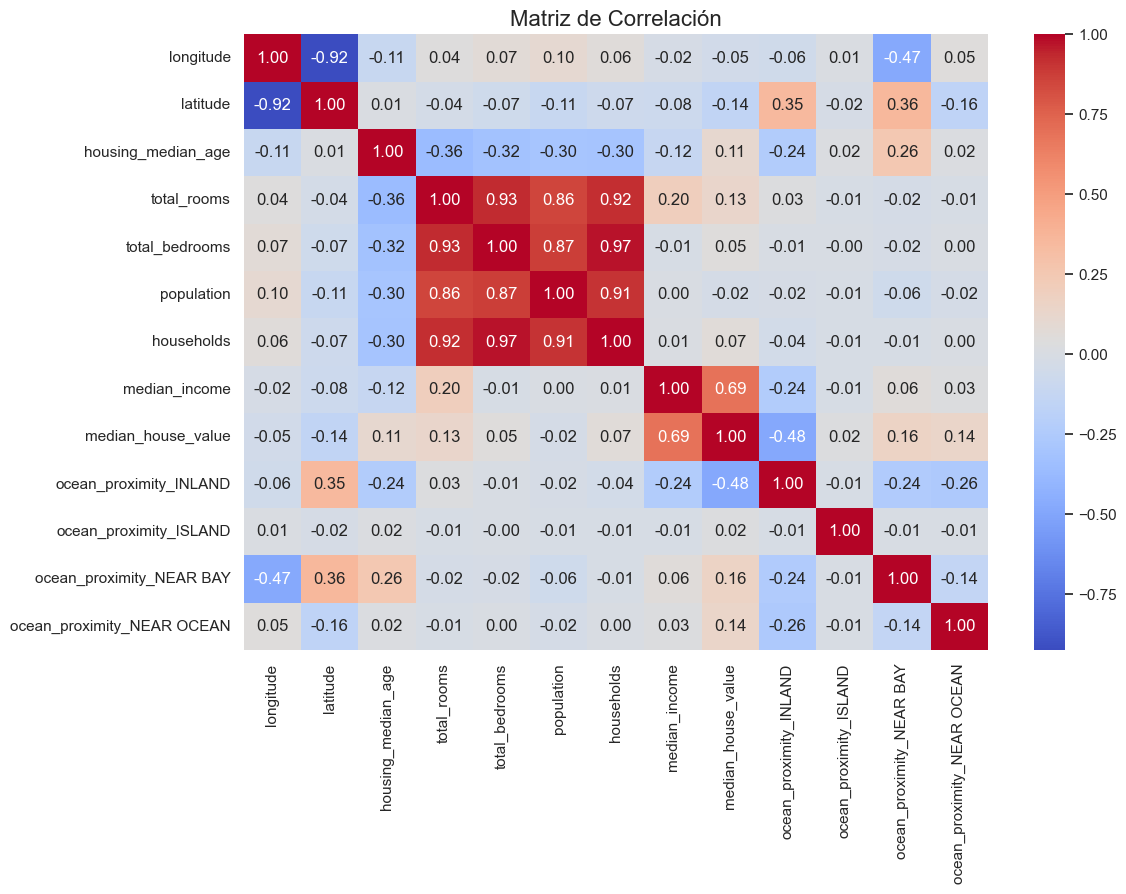

In [18]:
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación', fontsize=16)
plt.show()

**Observación Clave**: La característica `MedInc` (ingreso mediano) es la que tiene la correlación positiva más alta con `MedHouseVal` (nuestro objetivo).

## ⚙️ Paso 4: Preparación de Datos

Ahora, preparamos los datos para el entrenamiento del modelo.

In [19]:
# 1. Separar características (X) y objetivo (y)
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# 2. Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras')
print(f'Tamaño del conjunto de prueba: {X_test.shape[0]} muestras')

Tamaño del conjunto de entrenamiento: 16512 muestras
Tamaño del conjunto de prueba: 4128 muestras


### Escalado de Características

Muchos modelos de Machine Learning funcionan mejor cuando las características numéricas están en una escala similar. Usaremos `StandardScaler` para estandarizar los datos (media 0, desviación estándar 1).

In [20]:
# Crear el escalador
scaler = StandardScaler()

# Ajustar y transformar los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Transformar los datos de prueba (usando el mismo escalador ajustado en train)
X_test_scaled = scaler.transform(X_test)

print('Datos escalados correctamente.')

Datos escalados correctamente.


## 🤖 Paso 5: Entrenamiento de Modelos

Entrenaremos varios modelos de regresión para comparar su rendimiento.

In [ ]:
# Diccionario para almacenar los modelos
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

# Entrenar cada modelo
for name, model in models.items():
    print(f'Entrenando {name}...')
    model.fit(X_train_scaled, y_train)

print('\n✅ Todos los modelos han sido entrenados.')

Entrenando Linear Regression...
Entrenando Ridge Regression...
Entrenando Lasso Regression...
Entrenando Random Forest...

✅ Todos los modelos han sido entrenados.


## ⚖️ Paso 6: Evaluación de Modelos

Ahora, evaluamos el rendimiento de cada modelo en el conjunto de prueba, que son datos que nunca han visto.

In [22]:
# DataFrame para almacenar los resultados
results = pd.DataFrame(columns=['MAE', 'MSE', 'R²'])

for name, model in models.items():
    # Realizar predicciones
    y_pred = model.predict(X_test_scaled)
    
    # Calcular métricas
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Almacenar resultados
    results.loc[name] = [mae, mse, r2]

print('Resultados de la evaluación de modelos:')
display(results.sort_values(by='R²', ascending=False))

Resultados de la evaluación de modelos:


,MAE,MSE,R²
Random Forest,31631.018675,2.401861e+09,0.816709
Ridge Regression,50668.122931,4.908042e+09,0.625457
Lasso Regression,50670.132336,4.908383e+09,0.625431
Linear Regression,50670.738241,4.908477e+09,0.625424


### Interpretación de las Métricas

- **MAE (Mean Absolute Error)**: El error promedio absoluto de las predicciones. Un valor más bajo es mejor. (Ej: 0.33 significa que, en promedio, el modelo se equivoca en $33,000).
- **MSE (Mean Squared Error)**: Similar al MAE pero penaliza más los errores grandes. Un valor más bajo es mejor.
- **R² (Coeficiente de Determinación)**: Indica qué proporción de la varianza en la variable objetivo es predecible a partir de las características. Un valor más cercano a 1 es mejor. (Ej: 0.81 significa que el modelo explica el 81% de la variabilidad de los precios).

## 🌲 Paso 7: Análisis del Mejor Modelo (Random Forest)

El `RandomForestRegressor` ha dado los mejores resultados. Analicemos qué características considera más importantes.

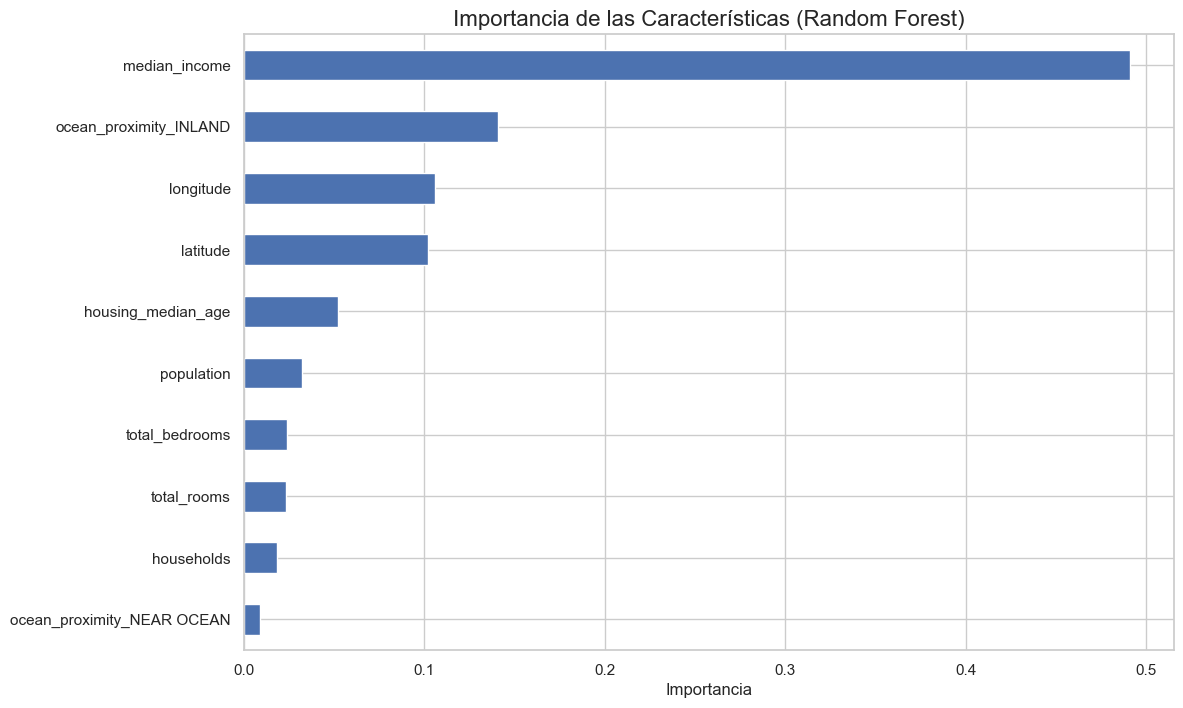

In [23]:
# Obtener el modelo Random Forest
rf_model = models['Random Forest']

# Obtener la importancia de las características
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Visualizar la importancia
plt.figure(figsize=(12, 8))
feature_importances.nlargest(10).sort_values().plot(kind='barh')
plt.title('Importancia de las Características (Random Forest)', fontsize=16)
plt.xlabel('Importancia')
plt.show()

## 🏁 Paso 8: Conclusión

En este proyecto, hemos seguido el flujo de trabajo completo de Machine Learning para predecir los precios de las viviendas en California.

### Hallazgos Clave:

1.  **El modelo `RandomForestRegressor` fue el de mejor rendimiento**, explicando aproximadamente el **81%** de la variabilidad en los precios de las viviendas (R² ≈ 0.81).
2.  Las características más importantes para predecir el precio son, en orden:
    - **Ingreso Mediano (`MedInc`)**: Confirma nuestra observación inicial del EDA.
    - **Ubicación Geográfica (`Longitude`, `Latitude`)**: La localización es un factor crucial en el precio.
    - **Antigüedad de la Vivienda (`HouseAge`)**.
3.  Los modelos de regresión lineal (Lineal, Ridge, Lasso) tuvieron un rendimiento inferior pero similar entre sí, explicando alrededor del 59% de la varianza. Esto sugiere que la relación entre las características y el precio no es puramente lineal.

### Próximos Pasos Posibles:

- **Ajuste de Hiperparámetros**: Usar técnicas como `GridSearchCV` o `RandomizedSearchCV` para encontrar la mejor configuración para el `RandomForestRegressor` y mejorar aún más su rendimiento.
- **Ingeniería de Características (Feature Engineering)**: Crear nuevas características combinando las existentes (ej: `habitaciones_por_persona`) para ver si mejoran el modelo.
- **Probar otros modelos**: Explorar modelos más avanzados como `GradientBoostingRegressor` o `XGBoost`.